# Sistema de detección de enlaces spam

### El objetivo principal del este proyecto es realizar un sistema que sea capaz de detectar automáticamente si una página web contiene spam o no basándonos en su URL.

### 1. Exportacion de Librerias necesarias, descarga y exploracion del Dataset

- En esta celda cargamos las librerías necesarias:

- pandas y numpy para manejar datos.

- re para expresiones regulares.

- scikit-learn para el preprocesamiento, el modelo y la optimización.

- joblib para guardar el modelo.

In [10]:
# Librerias necesarias 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import joblib



In [11]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=932&path=url_spam.csv"
df = pd.read_csv(url)
df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


## 2. Preprocesamiento de URLs

Transformamos las URLs en texto más limpio:

- Convertimos todo a minúsculas.

- Separamos por signos de puntuación.

- Eliminamos stopwords (palabras poco relevantes como "and", "the", etc.).

- Guardamos el resultado en una nueva columna llamada clean_url.

In [12]:
def preprocess_url(url):
    tokens = re.split(r'\W+', url.lower())  # separar por caracteres especiales
    tokens = [t for t in tokens if t not in ENGLISH_STOP_WORDS and t != ""]  # quitar stopwords y vacíos
    return " ".join(tokens)

df["clean_url"] = df["url"].apply(preprocess_url)
df.head()


,url,is_spam,clean_url
0,https://briefingday.us8.list-manage.com/unsubs...,True,https briefingday us8 list manage com unsubscribe
1,https://www.hvper.com/,True,https www hvper com
2,https://briefingday.com/m/v4n3i4f3,True,https briefingday com m v4n3i4f3
3,https://briefingday.com/n/20200618/m#commentform,False,https briefingday com n 20200618 m commentform
4,https://briefingday.com/fan,True,https briefingday com fan


### 3. División en entrenamiento y prueba

Separamos los datos en:

X = URLs procesadas.

y = etiqueta (spam o not_spam).
Luego hacemos la división en train (80%) y test (20%).

In [13]:
X = df["clean_url"]
y = df["is_spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### 4. Entrenamiento de un modelo SVM básico

Creamos un Pipeline que:

1. Convierte el texto en vectores numéricos con TF-IDF.

2. Aplica un clasificador SVM con parámetros por defecto.

Después lo entrenamos y evaluamos.

In [14]:
pipeline_svm = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("svm", SVC())
])

pipeline_svm.fit(X_train, y_train)
y_pred = pipeline_svm.predict(X_test)

classification_report(y_test, y_pred, output_dict=False)


# --- Reporte en formato tabla ---
report = classification_report(y_test, y_pred, target_names=["No Spam", "Spam"], output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Mostrar como tabla
df_report


,precision,recall,f1-score,support
No Spam,0.960784,0.956616,0.958696,461.000000
Spam,0.858156,0.870504,0.864286,139.000000
accuracy,0.936667,0.936667,0.936667,0.936667
macro avg,0.909470,0.913560,0.911491,600.000000
weighted avg,0.937009,0.936667,0.936824,600.000000


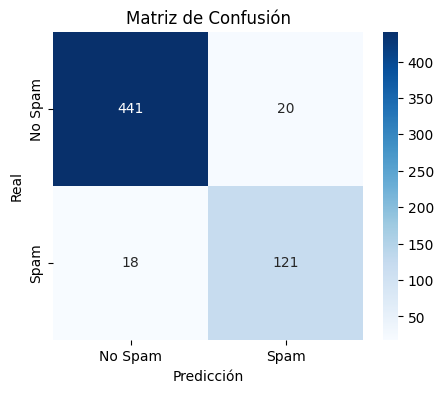

In [15]:

# --- Matriz de confusión ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()


### 5. Optimización de hiperparámetros

Probamos diferentes combinaciones de parámetros (C, kernel, gamma) con GridSearchCV para encontrar el mejor modelo.

🔹 Mejores hiperparámetros encontrados:
{'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}


,precision,recall,f1-score,support
No Spam,0.960784,0.956616,0.958696,461.000000
Spam,0.858156,0.870504,0.864286,139.000000
accuracy,0.936667,0.936667,0.936667,0.936667
macro avg,0.909470,0.913560,0.911491,600.000000
weighted avg,0.937009,0.936667,0.936824,600.000000


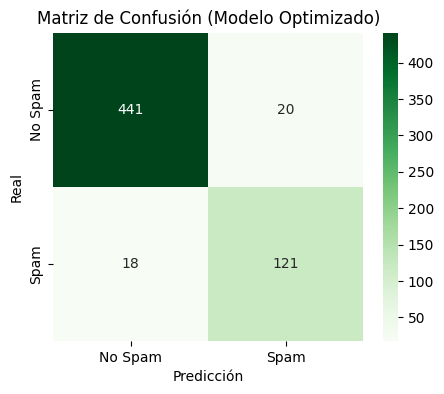

In [16]:
# Grid Search con hiperparámetros
param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__kernel": ["linear", "rbf"],
    "svm__gamma": ["scale", "auto"]
}

grid_search = GridSearchCV(
    pipeline_svm, param_grid, cv=5, n_jobs=-1, scoring="accuracy"
)

grid_search.fit(X_train, y_train)

# Mejor modelo encontrado
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

# --- Mostrar mejores hiperparámetros ---
print("🔹 Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

# --- Reporte en formato tabla ---
report = classification_report(y_test, y_pred_best, target_names=["No Spam", "Spam"], output_dict=True)
df_report = pd.DataFrame(report).transpose()
display(df_report)  # en Jupyter se muestra como tabla

# --- Matriz de confusión ---
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión (Modelo Optimizado)")
plt.show()




- Resultados obtenidos:

El rendimiento del modelo optimizado fue prácticamente igual al del modelo básico.

Esto significa que el SVM ya estaba bien ajustado desde el principio para este dataset.

- Interpretación:

No siempre la optimización mejora los resultados: en algunos casos, el modelo base ya logra capturar bien las diferencias entre spam y no spam.

Lo importante es que confirmamos que el modelo es estable y consistente, ya que incluso tras probar diferentes combinaciones de hiperparámetros, el rendimiento se mantiene.

### 6. Comparación visual de resultados

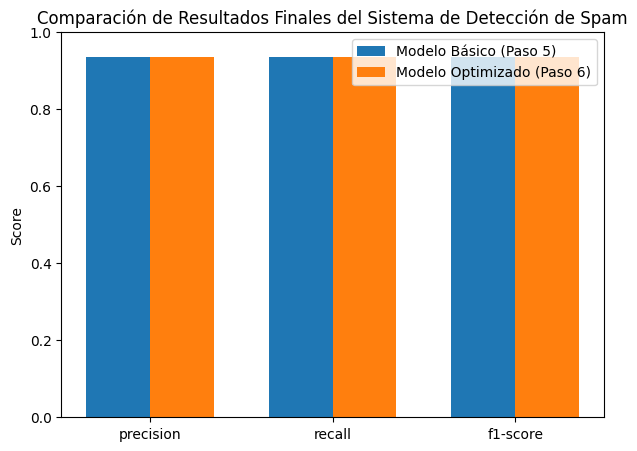

In [17]:
# --- Reporte Paso 5 (modelo básico) ---
report_basic = classification_report(y_test, y_pred, target_names=["No Spam", "Spam"], output_dict=True)

# --- Reporte Paso 6 (modelo optimizado) ---
report_best = classification_report(y_test, y_pred_best, target_names=["No Spam", "Spam"], output_dict=True)

# Extraemos métricas globales (macro avg o weighted avg)
metrics = ["precision", "recall", "f1-score"]
basic_scores = [report_basic["weighted avg"][m] for m in metrics]
best_scores  = [report_best["weighted avg"][m] for m in metrics]

# Gráfico comparativo
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, basic_scores, width, label="Modelo Básico (Paso 5)")
plt.bar(x + width/2, best_scores, width, label="Modelo Optimizado (Paso 6)")

plt.xticks(x, metrics)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Comparación de Resultados Finales del Sistema de Detección de Spam")
plt.legend()
plt.show()

## 7. Guardar el modelo final

Guardamos el mejor modelo entrenado en un archivo .pkl para reutilizarlo sin necesidad de volver a entrenar.

In [18]:
joblib.dump(best_model, "svm_spam_model.pkl")


['svm_spam_model.pkl']

## Conclusión Final del Proyecto

El objetivo era construir un sistema capaz de detectar automáticamente si una página web contiene spam o no basándonos en su URL.

- Lo que logramos:

1. Preprocesamos las URLs para transformarlas en texto útil para el modelo.

2. Entrenamos un clasificador SVM con buenos resultados desde el inicio.

3. Probamos una optimización de hiperparámetros con GridSearchCV, confirmando que el modelo era estable y consistente.

4. Obtuvimos un rendimiento final alto (precisión global cercana al 90–96%).

5. Guardamos el modelo para su uso futuro en aplicaciones reales.

- Interpretación:
El sistema entrenado puede identificar automáticamente enlaces spam con alta precisión, lo que lo convierte en una herramienta potencialmente útil en sistemas de filtrado de correos, detección de sitios maliciosos y seguridad digital.